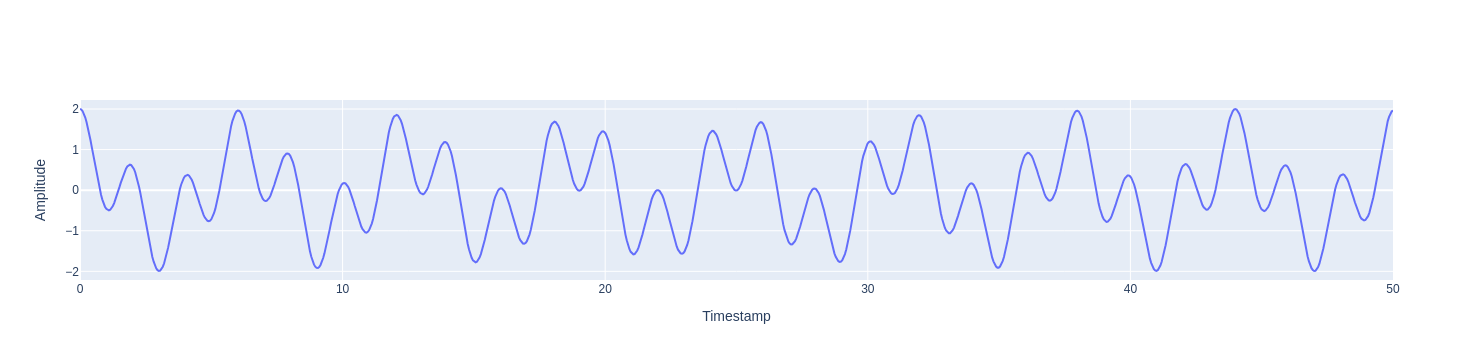

In [1]:
import numpy as np
import plotly.graph_objects as go

x_nonperiodic = np.linspace(0, 50, 1000)
y_nonperiodic = np.cos(x_nonperiodic) + np.cos(np.pi * x_nonperiodic)

fig = go.Figure(data=go.Scatter(x=x_nonperiodic, y=y_nonperiodic))
fig.update_layout(xaxis_title="Timestamp", yaxis_title="Amplitude")
fig.show()

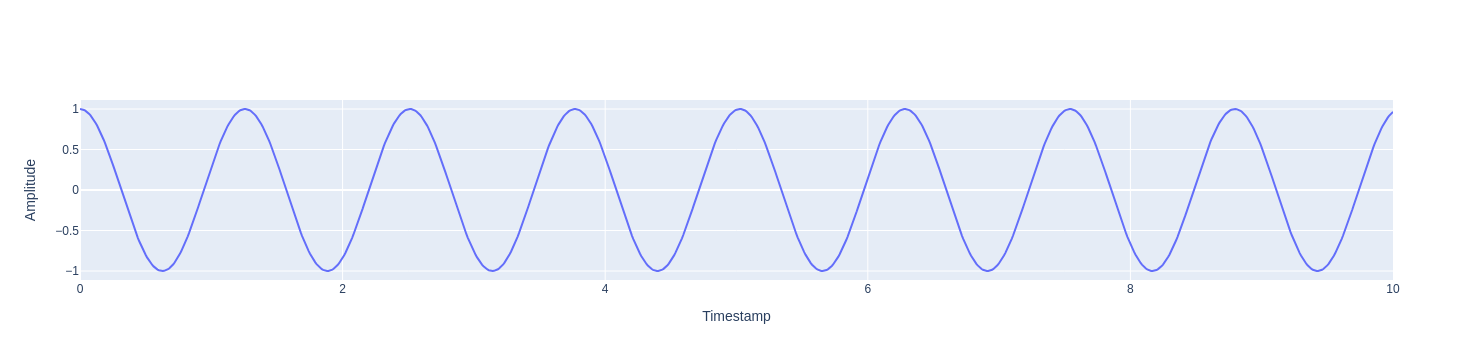

In [2]:
x_periodic = np.linspace(0, 10, 1000)
y_periodic = np.cos(5 * x_periodic)

fig = go.Figure(data=go.Scatter(x=x_periodic, y=y_periodic))
fig.update_layout(xaxis_title="Timestamp", yaxis_title="Amplitude")
fig.show()

Shape of embedded time series: (186, 6)
Optimal embedding dimension is 6 and time delay is 14


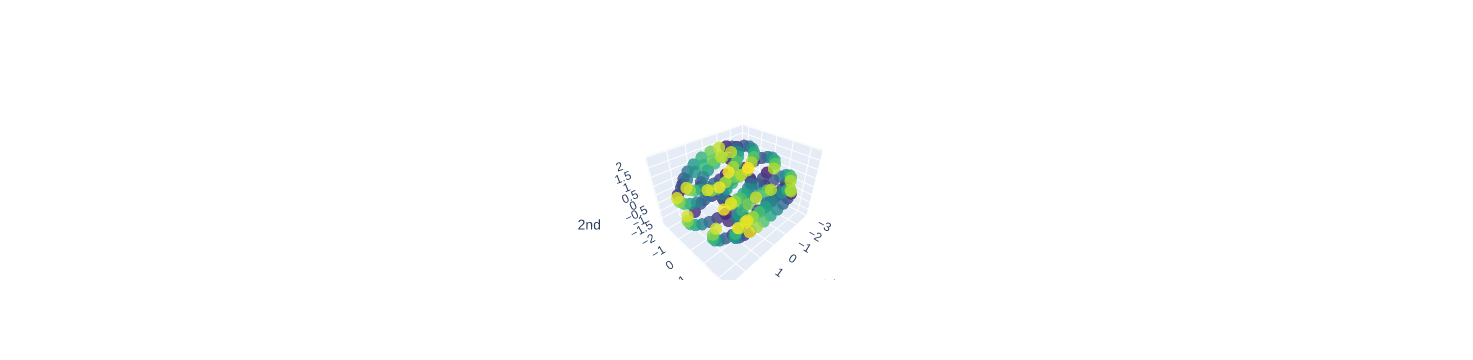

In [3]:
from gtda.time_series import SingleTakensEmbedding
from gtda.plotting import plot_heatmap, plot_point_cloud, plot_diagram, plot_betti_curves, plot_betti_surfaces

def fit_embedder(embedder: SingleTakensEmbedding, y: np.ndarray, verbose: bool=True) -> np.ndarray:
    """Fits a Takens embedder and displays optimal search parameters."""
    y_embedded = embedder.fit_transform(y)

    if verbose:
        print(f"Shape of embedded time series: {y_embedded.shape}")
        print(
            f"Optimal embedding dimension is {embedder.dimension_} and time delay is {embedder.time_delay_}"
        )

    return y_embedded
    
max_embedding_dimension = 30
max_time_delay = 30
stride = 5

embedder_nonperiodic = SingleTakensEmbedding(
    parameters_type="search",
    n_jobs=2,
    time_delay=max_time_delay,
    dimension=max_embedding_dimension,
    stride=stride,
)

y_nonperiodic_embedded = fit_embedder(embedder_nonperiodic, y_nonperiodic)
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
y_nonperiodic_embedded_pca = pca.fit_transform(y_nonperiodic_embedded)
plot_point_cloud(y_nonperiodic_embedded_pca)

Shape of embedded time series: (171, 6)
Optimal embedding dimension is 6 and time delay is 29


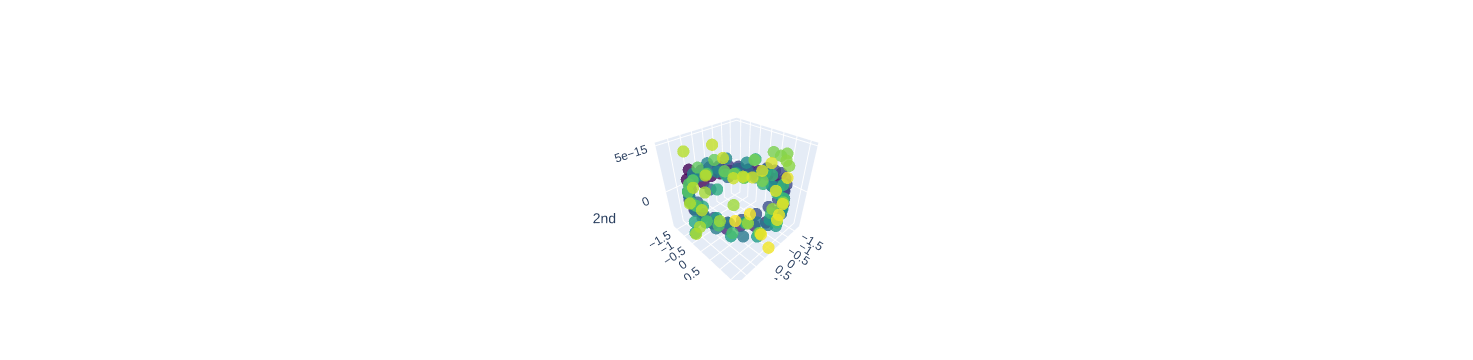

In [4]:
max_embedding_dimension = 30
max_time_delay = 30
stride = 5

embedder_periodic = SingleTakensEmbedding(
    parameters_type="search",
    time_delay=max_time_delay,
    dimension=max_embedding_dimension,
    stride=stride,
)

y_periodic_embedded = fit_embedder(embedder_periodic, y_periodic)
pca = PCA(n_components=3)
y_periodic_embedded_pca = pca.fit_transform(y_periodic_embedded)
plot_point_cloud(y_periodic_embedded_pca)

Persistence diagram for periodic signal


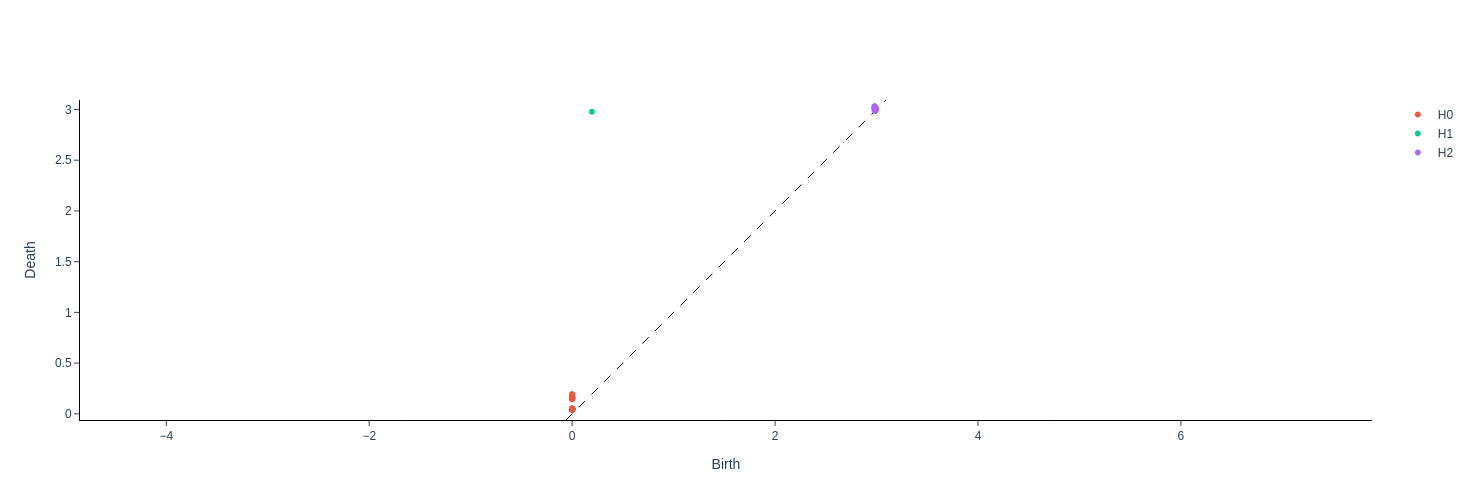

Persistence diagram for nonperiodic signal


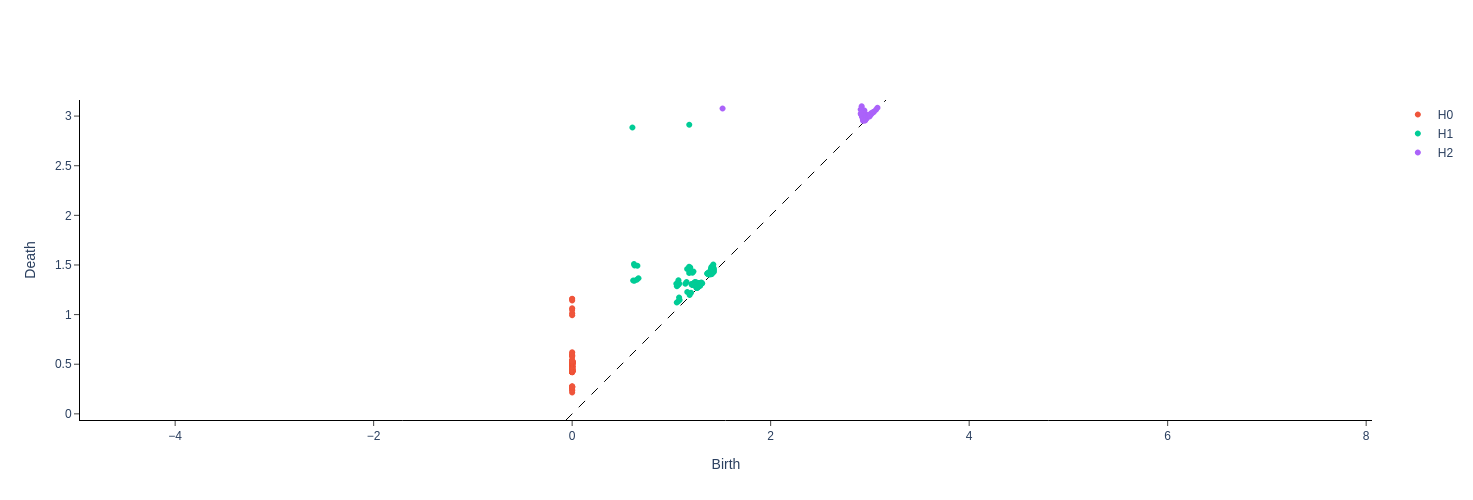

In [5]:
# add batch dimension for persistence calculation
y_periodic_embedded = y_periodic_embedded[None, :, :]
y_nonperiodic_embedded = y_nonperiodic_embedded[None, :, :]

from gtda.homology import VietorisRipsPersistence

# 0 - connected components, 1 - loops, 2 - voids
homology_dimensions = [0, 1, 2]

periodic_persistence = VietorisRipsPersistence(
    homology_dimensions=homology_dimensions, n_jobs=6, max_edge_length=10
)
print("Persistence diagram for periodic signal")
periodic_graph = periodic_persistence.fit_transform_plot(y_periodic_embedded)

nonperiodic_persistence = VietorisRipsPersistence(
    homology_dimensions=homology_dimensions, n_jobs=6
)
print("Persistence diagram for nonperiodic signal")
nonperiodic_graph = nonperiodic_persistence.fit_transform_plot(y_nonperiodic_embedded);


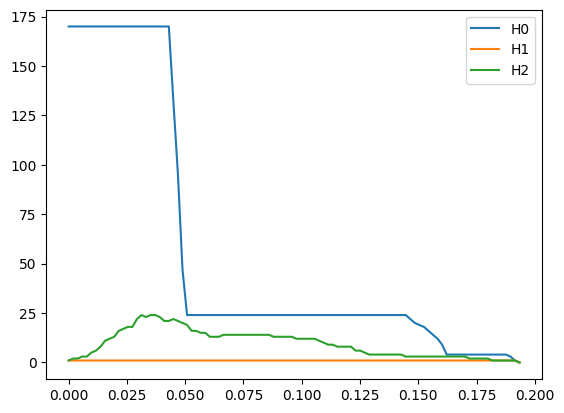

In [6]:
from gtda.diagrams import BettiCurve, PersistenceImage
import matplotlib.pyplot as plt
# Betti curves
bc = BettiCurve()
betti_curves = bc.fit_transform(periodic_graph)
betti = betti_curves[0]  # (3, 100)
x = bc.samplings_[0]
plt.plot(x, betti[0], label="H0")
plt.plot(x, betti[1], label="H1")
plt.plot(x, betti[2], label="H2")
plt.title("Betti Curves")
plt.legend()
plt.show()